In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("data_snow.csv")

# Preview
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (137779, 15)
        id  year  month day_of_week  vehicle_mass   region      road_type  \
0  6425561  2014      1   Wednesday           NaN  Uusimaa       no value   
1  6425563  2014      1    Thursday           NaN  Uusimaa       no value   
2  6463959  2014      1   Wednesday        1355.0    Lappi  regional road   
3  6463960  2014      1      Sunday           NaN    Lappi  regional road   
4  6464202  2014      1      Friday        1130.0    Lappi  regional road   

  Seriousness    lon    lat  snowfall_1  snowfall_2  snowfall_3  snowfall_4  \
0   No injury  24.70  60.15        0.35        0.00        0.07        0.00   
1   No injury  24.80  60.22        0.35        1.47        0.00        0.00   
2   No injury  23.52  68.38        1.89        1.54        0.00        0.00   
3   No injury  27.69  68.68        0.21        0.00        0.21        0.42   
4   No injury  28.02  66.69        0.00        0.00        0.00        0.00   

   snowfall_5  
0        0.00  
1 

In [3]:
df = df.dropna()

Transaltion

In [4]:
df['Seriousness'].value_counts(normalize=True)

Seriousness
No injury    0.738807
Injury       0.261193
Name: proportion, dtype: float64

In [5]:
df['location'] = "(" + df['lon'].astype(str) + ", " + df['lat'].astype(str) + ")"


In [6]:
df.head()

,id,year,month,day_of_week,vehicle_mass,region,road_type,Seriousness,lon,lat,snowfall_1,snowfall_2,snowfall_3,snowfall_4,snowfall_5,location
2,6463959,2014,1,Wednesday,1355.0,Lappi,regional road,No injury,23.52,68.38,1.89,1.54,0.0,0.0,0.0,"(23.52, 68.38)"
11,6464803,2014,1,Thursday,1135.0,Lappi,local road,No injury,25.51,66.42,0.84,0.84,0.0,0.0,0.0,"(25.51, 66.42)"
13,6465446,2014,1,Thursday,1378.0,Lappi,connector road,No injury,28.55,66.05,0.14,2.59,0.0,0.0,0.0,"(28.55, 66.05)"
14,6465447,2014,1,Wednesday,350.0,Pohjois-Pohjanmaa,connector road,Injury,29.13,66.17,1.12,6.30,0.0,0.0,0.0,"(29.13, 66.17)"
15,6465567,2014,1,Thursday,1559.0,Lappi,no value,No injury,25.73,66.50,0.35,0.91,0.0,0.0,0.0,"(25.73, 66.5)"


Feature Engineering

In [7]:
snowfall_cols = ['snowfall_1', 'snowfall_2', 'snowfall_3', 'snowfall_4', 'snowfall_5']

# Calculate average snowfall
df['avg_snowfall'] = df[snowfall_cols].mean(axis=1)

# Apply rule: if avg_snowfall < 3 cm, treat as 0 
#df['avg_snowfall'] = df['avg_snowfall'].apply(lambda x: 0 if x < 2 else x)

Define Target and Feature set

In [8]:
df = df.dropna(subset=['Seriousness'])

# Encode target variable: Injury = 1, No injury = 0
df['target'] = df['Seriousness'].apply(lambda x: 1 if x == 'Injury' else 0)

# Drop unnecessary columns
X1 = df.drop(columns=['id', 'Seriousness', 'target', 'lon', 'lat'] + snowfall_cols)
y1 = df['target']

# One-hot encode categorical variables (month, day_of_week)
X1 = pd.get_dummies(X1, drop_first=True)
print("Processed feature shape:", X1.shape)

Processed feature shape: (26578, 13478)


In [11]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

X_res, y_res = SMOTE().fit_resample(X1, y1)
print("Resampled feature shape:", X_res.shape)
print("Resampled target shape:", y_res.shape)
X = X_res
y = y_res

Resampled feature shape: (39272, 13478)
Resampled target shape: (39272,)


Train and Test Split

In [12]:
# Train (80%) + Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Split Temp (20%) into Validation (10%) + Test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42, stratify = y_temp)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


Train: (31417, 13478), Validation: (3927, 13478), Test: (3928, 13478)


In [13]:
y.value_counts(normalize=True)

target
0    0.5
1    0.5
Name: proportion, dtype: float64

In [14]:
df

,id,year,month,day_of_week,vehicle_mass,region,road_type,Seriousness,lon,lat,snowfall_1,snowfall_2,snowfall_3,snowfall_4,snowfall_5,location,avg_snowfall,target
2,6463959,2014,1,Wednesday,1355.0,Lappi,regional road,No injury,23.52,68.38,1.89,1.54,0.00,0.00,0.00,"(23.52, 68.38)",0.686,0
11,6464803,2014,1,Thursday,1135.0,Lappi,local road,No injury,25.51,66.42,0.84,0.84,0.00,0.00,0.00,"(25.51, 66.42)",0.336,0
13,6465446,2014,1,Thursday,1378.0,Lappi,connector road,No injury,28.55,66.05,0.14,2.59,0.00,0.00,0.00,"(28.55, 66.05)",0.546,0
14,6465447,2014,1,Wednesday,350.0,Pohjois-Pohjanmaa,connector road,Injury,29.13,66.17,1.12,6.30,0.00,0.00,0.00,"(29.13, 66.17)",1.484,1
15,6465567,2014,1,Thursday,1559.0,Lappi,no value,No injury,25.73,66.50,0.35,0.91,0.00,0.00,0.00,"(25.73, 66.5)",0.252,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137760,10212505,2021,12,Wednesday,11890.0,Varsinais-Suomen ELY,no value,Injury,22.34,60.44,0.00,0.00,0.07,1.82,2.03,"(22.34, 60.44)",0.784,1
137765,10215284,2021,12,Wednesday,1450.0,Uudenmaan ELY,no value,No injury,24.63,60.16,0.00,0.00,0.00,0.70,2.17,"(24.63, 60.16)",0.574,0
137770,10215293,2021,12,Thursday,1574.0,Pohjois-Savon ELY,no value,No injury,27.68,62.91,0.21,0.21,0.00,0.49,2.66,"(27.68, 62.91)",0.714,0
137772,10220819,2021,12,Wednesday,2650.0,Uudenmaan ELY,no value,No injury,24.96,60.17,0.00,0.07,0.00,0.84,1.68,"(24.96, 60.17)",0.518,0


Hypeparameter tuning

In [15]:
dt = DecisionTreeClassifier(class_weight = 'balanced', random_state=42)

# param_grid = {
#     'criterion': ['gini', 'entropy', 'log_loss'],
#     'max_depth': [3, 5, 10, 15, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': [None, 'sqrt', 'log2']
# }

In [16]:
# # Perform 5-fold CV on training data
# random_search = RandomizedSearchCV(
#     DecisionTreeClassifier(random_state=42),
#     param_distributions=param_grid,
#     n_iter=10,              
#     cv=3,                    
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=2,
#     random_state=42
# )

In [17]:
# random_search.fit(X_train, y_train)
# print("Best Parameters:", random_search.best_params_)

# best_dt = random_search.best_estimator_

In [18]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator = dt,
    param_grid = param_grid,
    cv = 5,
    n_jobs = 1,
    scoring = 'accuracy',
    verbose = 1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

best_dt = grid_search.best_estimator_

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


Evaluate on the validation set

In [19]:
y_val_pred = best_dt.predict(X_val)
y_val_proba = best_dt.predict_proba(X_val)[:, 1]

print("\n--- Validation Results ---")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))


--- Validation Results ---
Accuracy: 0.8062133944486886
ROC AUC: 0.8061387449900553


Retrain on and Evaluate

In [20]:
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

best_dt.fit(X_final_train, y_final_train)

y_test_pred = best_dt.predict(X_test)
y_test_proba = best_dt.predict_proba(X_test)[:, 1]

print("\nFinal Test Results")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_proba))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Final Test Results
Accuracy: 0.8026985743380856
ROC AUC: 0.8026985743380854

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.85      0.81      1964
           1       0.83      0.76      0.79      1964

    accuracy                           0.80      3928
   macro avg       0.81      0.80      0.80      3928
weighted avg       0.81      0.80      0.80      3928



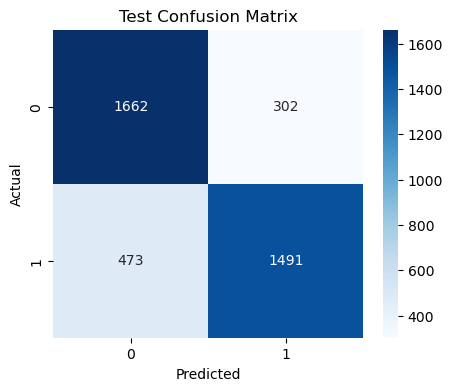

In [21]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

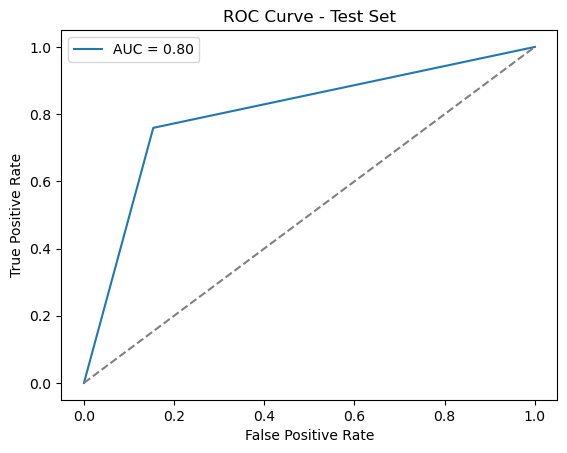

In [22]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_test_proba):.2f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC Curve - Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Feature Importance

C:\Users\User\AppData\Local\Temp\ipykernel_17384\511601358.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_features.values, y = top_features.index, palette = "mako")


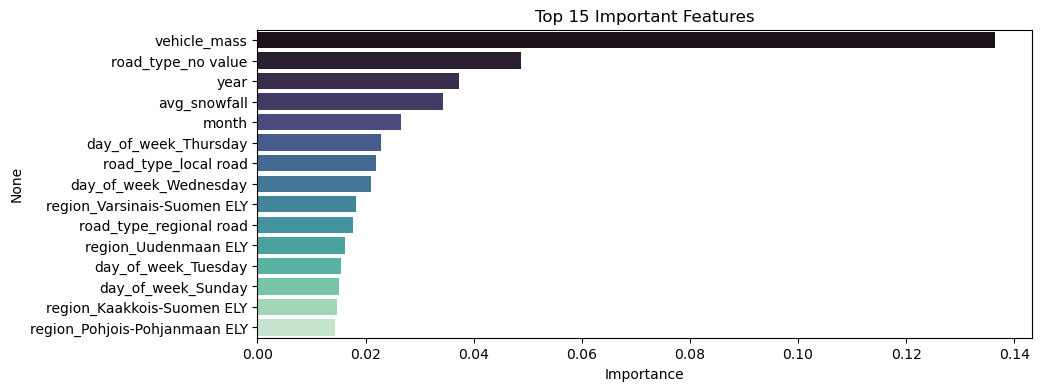

In [23]:
importances = pd.Series(best_dt.feature_importances_, index = X.columns)
top_features = importances.sort_values(ascending = False).head(15)

plt.figure(figsize=(10,4))
sns.barplot(x = top_features.values, y = top_features.index, palette = "mako")
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

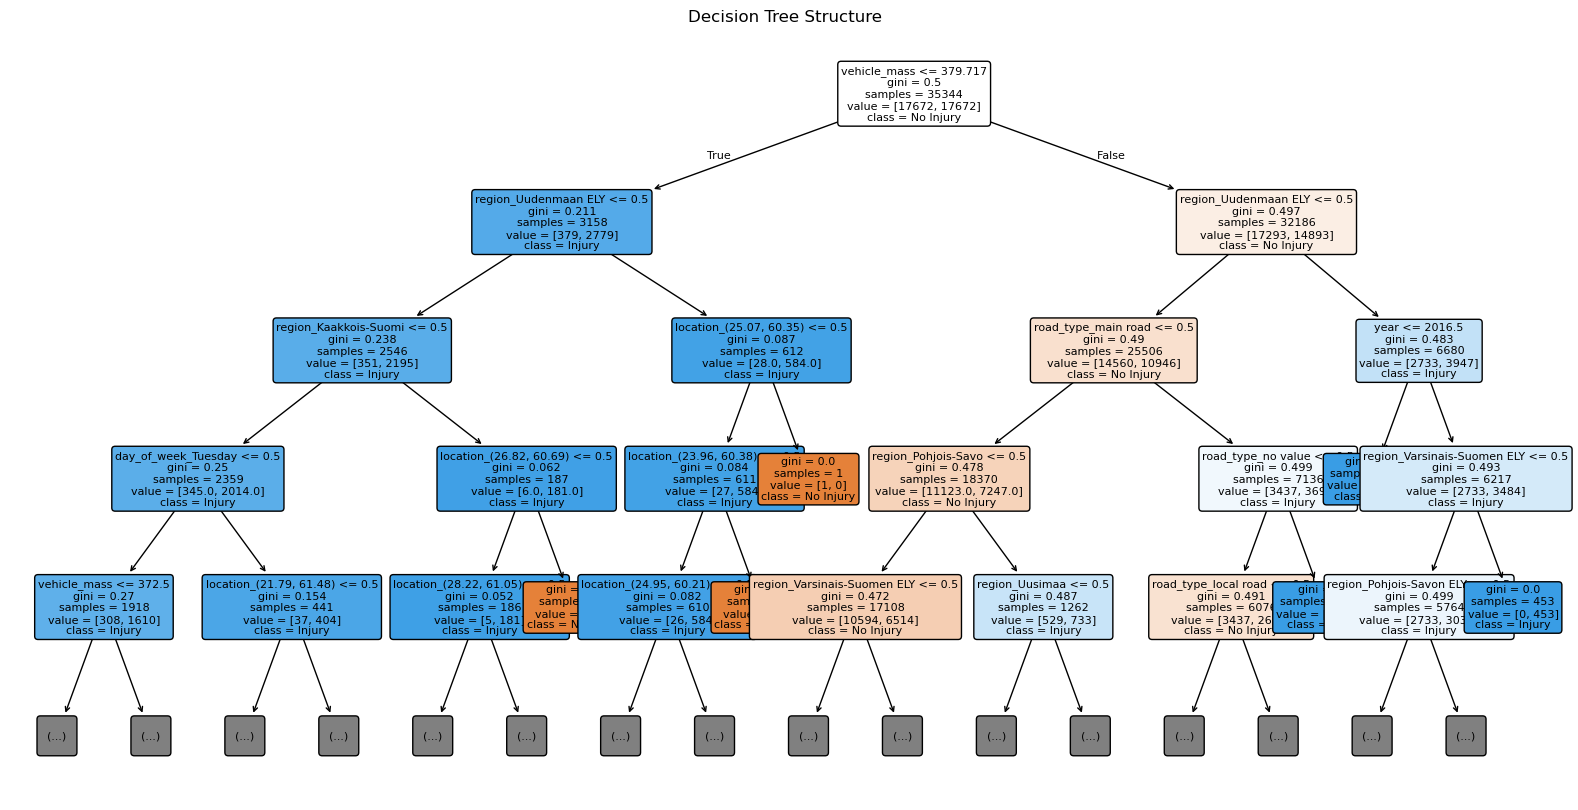

In [32]:
plt.figure(figsize=(20,10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['No Injury', 'Injury'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title("Decision Tree Structure")
plt.show()